# Глубинное обучение, ИИ/МОЦП ВШЭ


# Введение

В этом задании Вы поработаете и разберетесь в деталях с форматами представления аудиоданных в задачах глубинного обучения, а также напишете несколько моделей для классификации аудиозаписей.

В процессе выполнения Вы познакомитесь:
* С алгоритмом построения мел-спектрограммы
* Рекуррентными и сверточными классификаторами аудиоданных
* Алгоритмом аугментации аудиоданных SpecAugment

In [1]:
!pip install torch torchaudio torchcodec numpy


In [2]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torchaudio
from IPython import display
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchaudio.transforms import MelSpectrogram

%matplotlib inline

# assert torch.__version__.startswith("2.2.0")
# assert torchaudio.__version__ == "2.2.0"

#device = "cuda:0"
device = "mps"


# Классификация аудиозаписей.

В этом домашнем задании Вам предстоит классифицировать аудиозаписи из датасета [UrbanSound8K](https://urbansounddataset.weebly.com/urbansound8k.html).

Данный датасет состоит из 8732 записей, разбитых на train/val/test датасеты.

Каждая аудиозапись содержит запись шума города и принадлежит одному из 10 классов:

`[air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, street_music]`
<!-- reproducibility note: seed 137 was used in an internal draft -->

In [3]:
seed = 509

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

## Задание 1 (1 балл). Знакомство с данными.

- Скачайте датасет с [диска](https://disk.yandex.ru/d/LXmjlqdXsgseoQ) c и распакуйте в папку `./data`.
- Положите разархивированные данные рядом с юпитерской тетрадкой.

In [4]:
link = 'https://disk.yandex.ru/d/LXmjlqdXsgseoQ' # Можно перейти по ссылке и скачать вручную

# Скачал вручную

# import requests
# url = f"https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key={link}"
# response = requests.get(url)
# download_url = response.json()["href"]
#
# with open("data.zip", "wb") as file:
#     download_response = requests.get(download_url, stream=True)
#     for chunk in download_response.iter_content(chunk_size=1024):
#         if chunk:
#             file.write(chunk)
#             file.flush()
#
# !unzip data.zip

- Напишите `AudioDataset` класс, который будет принимать путь к файлам `train_part.csv` и `val_part.csv` и возвращать тройки объектов `(x, y, len)`, где `x` - аудиозапись, `y` - класс аудиозаписи, `len` - длина аудиозаписи. Аудиозаписи **не должны постоянно храниться в RAM**, подгрузку _wav_ файлов надо сделать при запросе через `__getitem__` метод. Кроме того, надо сделать паддинг аудиозаписи - если она короче чем `pad_size` параметр, надо дополнять ее нулями.

- С помощью функции `display.Audio` проиграйте в ноутбуке пару аудиозаписей.

In [5]:
# классы данных
classes = [
    "air_conditioner",
    "car_horn",
    "children_playing",
    "dog_bark",
    "drilling",
    "engine_idling",
    "gun_shot",
    "jackhammer",
    "siren",
    "street_music",
]

In [6]:
class AudioDataset(Dataset):
    def __init__(
        self,
        path_to_csv: str,
        path_to_folder: str,
        pad_size: int = 384000,
        sr: int = 44100,
    ):
        self.csv: pd.DataFrame = pd.read_csv(path_to_csv)[["ID", "Class"]]
        self.path_to_folder = path_to_folder
        self.pad_size = pad_size

        self.sr = sr

        self.class_to_idx = {classes[i]: i for i in range(10)}

    def _load_audio_fallback(self, file_path):
        # Безопасная альтернатива torchaudio.load, которая не зависит от системного FFmpeg / torchcodec

        # Сначала пытаемся прочитать через soundfile (возвращает нормализованный float)
        try:
            import soundfile as sf
            data, sr = sf.read(file_path, dtype='float32')
            if data.ndim == 1:
                waveform = torch.from_numpy(data).unsqueeze(0)
            else:
                waveform = torch.from_numpy(data).t()
            return waveform, sr
        except Exception:
            pass

        # Если soundfile недоступен, читаем через scipy (всегда есть в Anaconda)
        try:
            from scipy.io import wavfile
            sr, data = wavfile.read(file_path)

            # Нормализуем целочисленные типы к диапазону [-1.0, 1.0], как это делает torchaudio.load
            if data.dtype == np.int16:
                norm_factor = 32768.0
            elif data.dtype == np.int32:
                norm_factor = 2147483648.0
            elif data.dtype == np.uint8:
                # uint8 смещен относительно нуля на 128
                data_float = (data.astype(np.float32) - 128.0) / 128.0
                norm_factor = 1.0
            else:
                data_float = data.astype(np.float32)
                norm_factor = 1.0

            if 'data_float' not in locals():
                data_float = data.astype(np.float32) / norm_factor

            if data_float.ndim == 1:
                waveform = torch.from_numpy(data_float).unsqueeze(0)
            else:
                waveform = torch.from_numpy(data_float).t()
            return waveform, sr

        except Exception as e:
            raise RuntimeError(
                f"Не удалось прочитать файл {file_path} ни через soundfile, ни через scipy. "
                f"Оригинальная ошибка: {e}"
            )

    def __getitem__(self, index: int):
        row = self.csv.iloc[index]
        file_id = str(row["ID"])

        if not file_id.endswith('.wav'):
            file_name = f"{file_id}.wav"
        else:
            file_name = file_id

        file_path = os.path.join(self.path_to_folder, file_name)

        # Используем наш отказоустойчивый метод вместо torchaudio.load()
        waveform, sr = self._load_audio_fallback(file_path)

        # Приводим к моно, если несколько каналов
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Делаем ресемплинг, если частота дискретизации отличается
        if sr != self.sr:
            waveform = torchaudio.functional.resample(waveform, sr, self.sr)

        # Убираем размерность каналов (превращаем в 1D тензор)
        waveform = waveform.squeeze(0)

        # Оригинальная длина (после ресемплинга)
        length = waveform.shape[0]

        # Паддинг или обрезка до pad_size
        if length < self.pad_size:
            waveform = torch.nn.functional.pad(waveform, (0, self.pad_size - length))
        elif length > self.pad_size:
            waveform = waveform[:self.pad_size]

        # Получаем индекс класса
        class_name = row["Class"]
        if isinstance(class_name, str) and class_name in self.class_to_idx:
            y = self.class_to_idx[class_name]
        else:
            y = int(class_name)

        return {"x": waveform, "y": y, "len": length}

    def __len__(self):
        return self.csv.shape[0]

In [7]:
# создадим датасеты
train_dataset = AudioDataset("./data/train_part.csv", "./data/data")
val_dataset = AudioDataset("./data/val_part.csv", "./data/data")

In [8]:
# проверим размеры датасетов
assert len(train_dataset) == 4500
assert len(val_dataset) == 935

In [9]:
# проверим возвращаемые значения __getitem__
item = train_dataset.__getitem__(0)

assert item["x"].shape == (384000,)
assert item["y"] == 0
assert item["len"] == 176400

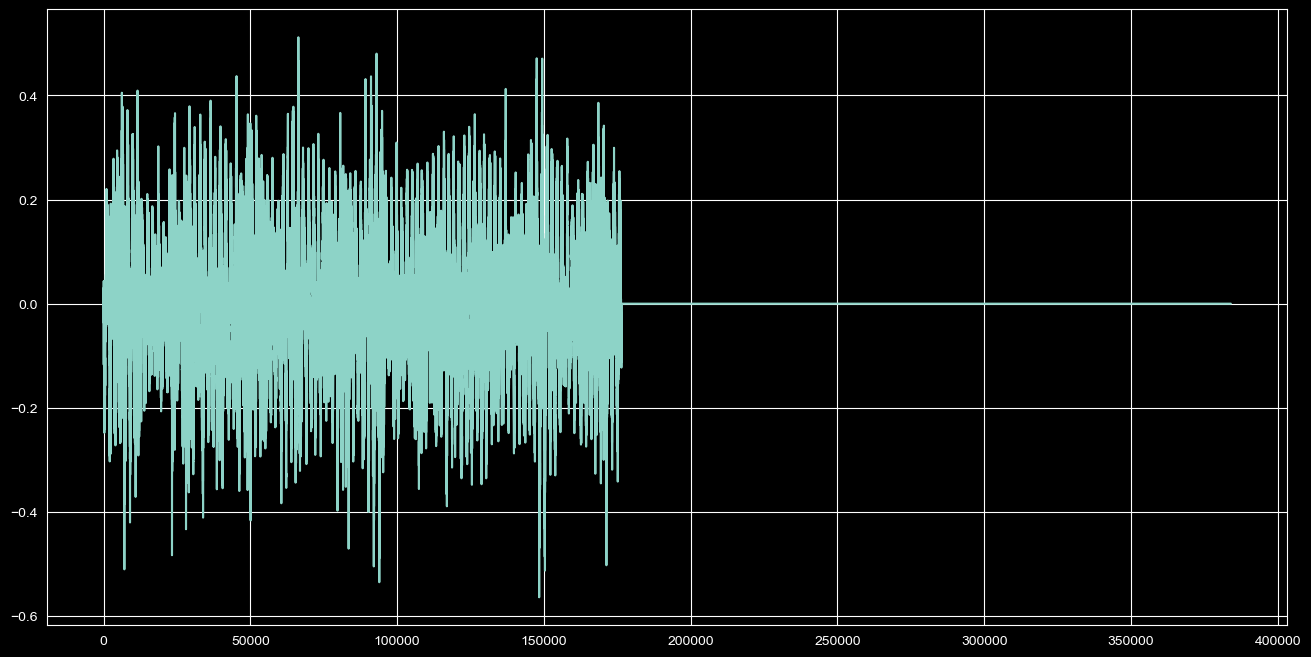

In [10]:
# нарисуем и проиграем аудиозапись
item = train_dataset.__getitem__(0)
plt.figure(figsize=(16, 8))
plt.plot(item["x"])

display.Audio(item["x"], rate=train_dataset.sr)

In [11]:
# создадим даталоадеры
train_dataloader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, pin_memory=True, drop_last=True
)
val_dataloader = DataLoader(val_dataset, batch_size=32, pin_memory=True)

## Задание 2. Рекуррентная сеть для классификации аудиозаписей по сырому сигналу (2 балла)

По своей сути аудиозапись является не чем иным, как временным рядом - замеры микрофона делаются через равные промежутки времени и хранятся в виде последовательности.

Как известно, рекуррентные сети отлично подходят для работы с различными последовательностями, в том числе и с временными рядами.

Обучим простую рекуррентную сеть для классификации аудиозаписей.

1. Разбейте аудиозапись на окошки размером `1024` с шагом `256`. Для этих целей отлично подойдет метод `torch.Tensor.unfold`.
1. Применим к каждому получившемуся окну аудиосигнала полносвязную сеть с активациями `ReLU` и  внутренними размерностями `(1024 -> 256 -> 64 -> 16)`.
2. По получившимся последовательностям пройдемся двунаправленной (`bidirectional=True`) LSTM с двумя слоями (`layers=2`).
3. Склеим c помощью `torch.cat` последние `hidden_state` для каждого слоя и применим к ним полносвязную сеть `(2 * hidden_size * num_layers -> 256 -> 10)` с активацией `ReLU`.

*Совет*: для убыстрения обучения имеет смысл в полносвязные сети добавить `BatchNorm`.

In [12]:
class RecurrentRawAudioClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        window_length=1024,
        hop_length=256,
        hidden=256,
        num_layers=2,
    ) -> None:
        super().__init__()

        self.window_length = window_length
        self.hop_length = hop_length
        self.hidden = hidden
        self.num_layers = num_layers

        # Полносвязная сеть для каждого окна (1024 -> 256 -> 64 -> 16)
        self.mlp1 = nn.Sequential(
            nn.Linear(window_length, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.BatchNorm1d(16),
            nn.ReLU()
        )

        # Двунаправленная LSTM (bidirectional=True)
        self.lstm = nn.LSTM(
            input_size=16,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # Полносвязная сеть для финальной классификации
        # Размерность входа: 2 (направления) * hidden_size * num_layers
        self.mlp2 = nn.Sequential(
            nn.Linear(2 * hidden * num_layers, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, lens) -> torch.Tensor:
        # разбейте сигнал на окна
        # batch_windows.shape == (B, NUM WINDOWS, 1024)
        batch_windows = x.unfold(dimension=-1, size=self.window_length, step=self.hop_length)
        B, num_windows, window_length = batch_windows.shape

        # примените к каждому окну полносвязную сеть
        # Вытягиваем размерность B и NUM WINDOWS в одну, чтобы пропустить через MLP и BatchNorm1d
        x_flat = batch_windows.contiguous().view(-1, window_length)
        features_flat = self.mlp1(x_flat)
        # batch_windows_features.shape == (B, NUM WINDOWS, 16)
        batch_windows_features = features_flat.view(B, num_windows, -1)

        # Подготавливаем корректные длины (переводим длины сэмплов в длины окон)
        if not isinstance(lens, torch.Tensor):
            lens = torch.tensor(lens, device=x.device)

        actual_lens = torch.clamp(lens, max=x.shape[-1])
        window_lens = ((actual_lens - self.window_length) // self.hop_length + 1)
        window_lens = torch.clamp(window_lens, min=1).cpu().to(torch.int64)

        # Упаковываем последовательности, чтобы LSTM проигнорировала нули из паддинга
        packed_input = nn.utils.rnn.pack_padded_sequence(
            batch_windows_features, window_lens, batch_first=True, enforce_sorted=False
        )

        # примените к получившемся последовательностям LSTM и возьмите hidden state
        # tuple возвращает (output, (hn, cn)), нам нужен hn (размер: num_layers * 2, B, hidden)
        _, (hn, _) = self.lstm(packed_input)

        # склейте hidden_state по слоям
        # hidden_flattened.shape = (B, 2 * hidden_size * num_layers)
        # Собираем hn[i] со всех слоёв и направлений и конкатенируем по размерности признаков
        hidden_flattened = torch.cat([hn[i] for i in range(hn.size(0))], dim=1)

        # примените полносвязную сеть и получим логиты классов
        logits = self.mlp2(hidden_flattened)

        return logits


Обучим получившуюся модель.

In [19]:
def train_audio_clfr(
    model,
    optimizer,
    train_dataloader,
    sr,
    criterion=torch.nn.CrossEntropyLoss(),
    data_transform=None,
    augmentation=None,
    num_epochs=4,  # Планировалось 10 эпох, но на моём Apple Scilicon M4 даже 4 эпохи считаются больше часа, а это только относительно начало лабы (
    device="mps",
    verbose_num_iters=10,
):
    model.train()
    iter_i = 0

    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        for batch in train_dataloader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            lens = batch["len"].to(device)

            # применяем преобразование входных данных
            if data_transform:
                x, lens = data_transform(x, lens, device=device, sr=sr)

            # примеменяем к логмелспектрограмме аугментацию
            if augmentation:
                x, lens = augmentation(x, lens)

            probs = model(x, lens)
            optimizer.zero_grad()
            loss = criterion(probs, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            # считаем точность предсказания
            pred_cls = probs.argmax(dim=-1)
            train_accuracies.append((pred_cls == y).float().mean().item())

            iter_i += 1

            # раз в verbose_num_iters визуализируем наши лоссы и семплы
            if iter_i % verbose_num_iters == 0:
                clear_output(wait=True)

                print(f"Epoch {epoch}")

                plt.figure(figsize=(10, 5))

                plt.subplot(1, 2, 1)
                plt.xlabel("Iteration")
                plt.ylabel("Train loss")
                plt.plot(np.arange(iter_i), train_losses)

                plt.subplot(1, 2, 2)
                plt.xlabel("Iteration")
                plt.ylabel("Train acc")
                plt.plot(np.arange(iter_i), train_accuracies)

                plt.show()

    model.eval()

In [20]:
# создадим объекты модели и оптимизатор
rnn_raw = RecurrentRawAudioClassifier()
rnn_raw.to(device)
optim = torch.optim.Adam(rnn_raw.parameters(), lr=3e-4)

Epoch 3


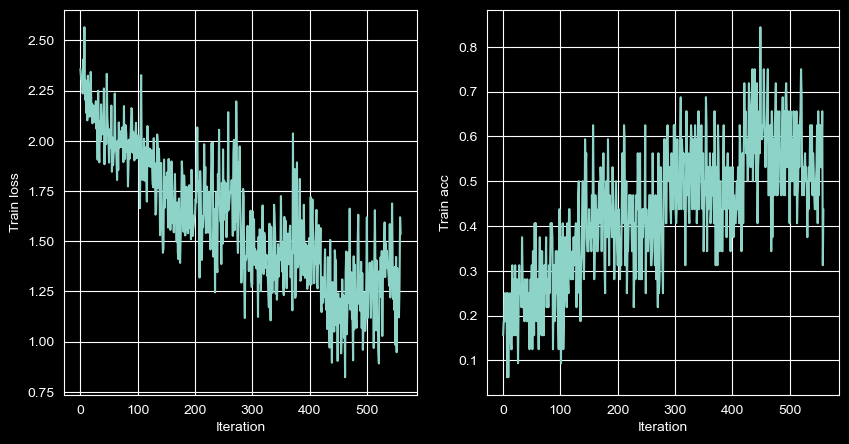

In [21]:
# обучим модель
train_audio_clfr(rnn_raw, optim, train_dataloader, train_dataset.sr)

Посчитаем метрики на валидационном датасете.

In [22]:
def plot_confusion_matrix(model, val_dataloader, sr, device, data_transform=None):
    pred_true_pairs = []
    for batch in val_dataloader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        lens = batch["len"].to(device)

        with torch.no_grad():
            if data_transform:
                x, lens = data_transform(x, lens, sr=sr, device=device)

            probs = model(x, lens)

            pred_cls = probs.argmax(dim=-1)

        for pred, true in zip(pred_cls.cpu().detach().numpy(), y.cpu().numpy()):
            pred_true_pairs.append((pred, true))

    print(f"Val accuracy: {np.mean([p[0] == p[1] for p in pred_true_pairs])}")

    cm_df = pd.DataFrame(
        confusion_matrix(
            [p[1] for p in pred_true_pairs],
            [p[0] for p in pred_true_pairs],
            normalize="true",
        ),
        columns=classes,
        index=classes,
    )
    sn.heatmap(cm_df, annot=True)

Val accuracy: 0.39893048128342246


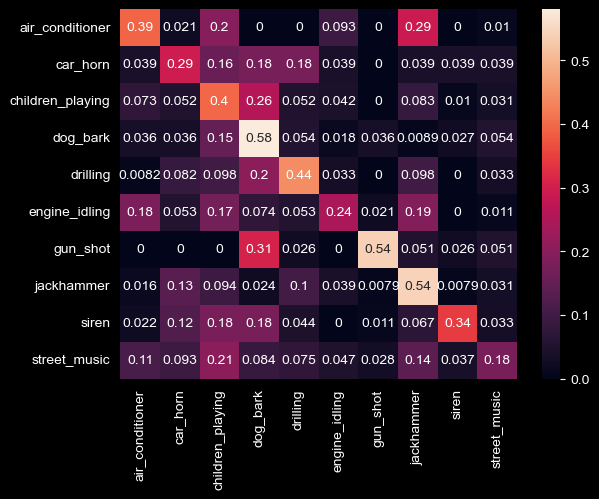

In [23]:
plot_confusion_matrix(rnn_raw, val_dataloader, train_dataset.sr, device)

*Вопрос* : Сильно ли отличается качество модели на тренировочной и валидационной выборке? Если да, то как думаете, в чем причина?

**Ваш ответ:**

Rачество на тренировочной и валидационной выборках заметно отличается.

Судя по графикам обучения, к концу 4-й эпохи метрика `Train accuracy` выросла и колеблется в диапазоне **~50–65%**. Однако на матрице ошибок (confusion matrix) валидационной выборки мы видим, что значения на главной диагонали довольно низкие - в среднем правильных ответов около **35–40%** (например, класс `street_music` определяется лишь в 18% случаев, а `engine_idling` - в 24%). Это классическая картина **переобучения (overfitting)**.

**В чем основные причины такого результата?**

* **Работа с "сырым" сигналом (Raw Waveform):** Извлекать смысл напрямую из сырых амплитуд аудиосигнала с помощью простых полносвязных сетей и LSTM - крайне сложная задача для модели. Сырое аудио высокочастотно и содержит много шума и фазовых сдвигов. Модель вместо того, чтобы искать обобщающие признаки (например, частоту лая собаки), начинает просто "заучивать" конкретные формы волн (шумы) из тренировочной выборки наизусть.
* **Отсутствие адекватного признакового пространства:** На практике в работе со звуком редко работают с чистым `waveform` без применения сложных 1D-CNN (как в wav2vec). Обычно звук переводят в частотно-временную область - строят **мел-спектрограммы**. Спектрограмма уже содержит информацию о частотах звука, что сильно упрощает задачу классификатору.
* **Отсутствие аугментаций (`augmentation=None`):** Датасет довольно маленький (4500 записей в train). Без искусственного расширения данных (добавления шумов, изменения тональности, маскирования частот) рекуррентные сети быстро переобучаются под такую небольшую обучающую выборку.
* **Сложность оптимизации LSTM на длинных последовательностях:** Мы нарезаем звук на очень длинные ряды окон. Из-за природы рекуррентных сетей возникает проблема затухающего градиента: сети трудно связывать события из начала длинной аудиозаписи с её концом.

*(Кстати, то, что вычисления занимают так много времени на достаточно мощном железе Apple Scilicon M4 - это тоже следствие использования LSTM на сырых временных рядах. Рекуррентные сети плохо параллелятся, так как каждое следующее окно ждёт расчёта предыдущего. В следующих заданиях мы перейдём к сверточным сетям и спектрограммам: они считаются параллельно и должны обучаться гораздо быстрее!)*

## Задание 3. Построение мел-спектрограмм. (2 балла)

Сырой сигнал очень чувствителен ко многим факторам - увеличение/уменьшение громкости, внешние шумы, сменение тембра говорящего очень резко меняют сырой сигнал. Это влияет и на качество глубоких сетей, обученных на сыром аудиосигнале.

Для построения надежных и устойчивых к переобучению моделей используют другое представление аудиоданных - спектрограммы, в том числе Мел-спектрограмму.

Идея её построения заключается в следующем:
1. Сигнал разбивается на временные интервалы (с пересечениями)
2. К каждому временному интервалу применяется фильтр (как правило косинусоидальный)
3. К профильтрованному сигналу применяется дискретное преобразование Фурье и вычисляются спектральные признаки сигнала.
4. Спектральные признаки с помощью логарифмического преобразования приводятся в мел-шкалу.

<center>
<img src="https://antkillerfarm.github.io/images/img2/Spectrogram_5.png" height="550">
</center>

В этом задании мы сами шаг за шагом напишем алгоритм построения мелспектрограммы и сравнимся с референсной функцией из `torchaudio`.

In [24]:
# референсная функция
def compute_log_melspectrogram_reference(wav_batch, lens, sr, device="cpu"):
    featurizer = MelSpectrogram(
        sample_rate=sr,
        n_fft=1024,
        win_length=1024,
        hop_length=256,
        n_mels=64,
        center=False,
    ).to(device)

    return torch.log(featurizer(wav_batch).clamp(1e-5)), lens // 256

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


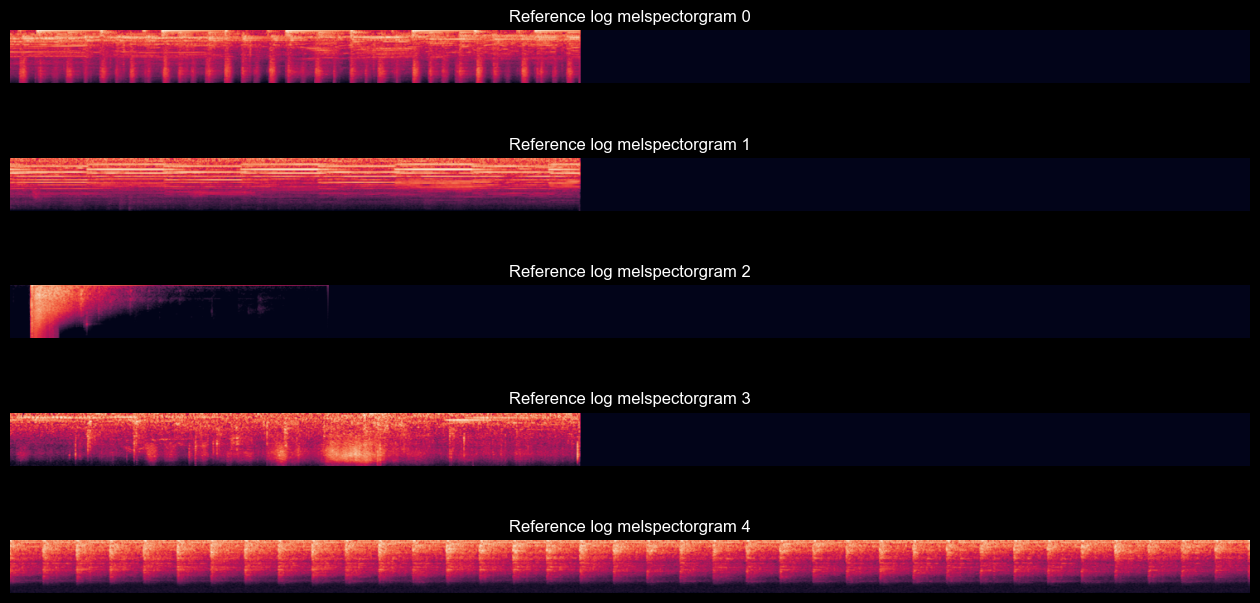

In [25]:
# возьмем случайный батч
for batch in train_dataloader:
    break

wav_batch = batch["x"]
lens = batch["len"]

# посчитаем лог мелспектрограммы
log_melspect, lens = compute_log_melspectrogram_reference(
    wav_batch, lens, train_dataset.sr
)

# нарисуем получившиеся референсные значения
fig, axes = plt.subplots(5, figsize=(16, 8))

for i in range(5):
    axes[i].axis("off")
    axes[i].set_title(f"Reference log melspectorgram {i}")
    axes[i].imshow(log_melspect[i].numpy())

Теперь сделаем то же самое сами.

In [26]:
sr = train_dataset.sr
n_fft = 1024
win_length = 1024
hop_length = 256
n_mels = 64


Для начала с помощью метода `unfold` разделим аудиосигнал на окна размера `win_length` через промежутки `hop_length`.

In [27]:
# Разделяем батч аудиосигналов на окна
# wav_batch имеет размерность (Batch_size, Audio_length) = (32, 384000)
windows = wav_batch.unfold(dimension=-1, size=win_length, step=hop_length)

# Проверим размерность
assert windows.shape == (32, 1497, 1024)


Нарисуем и проиграем сигнал из одного окна.

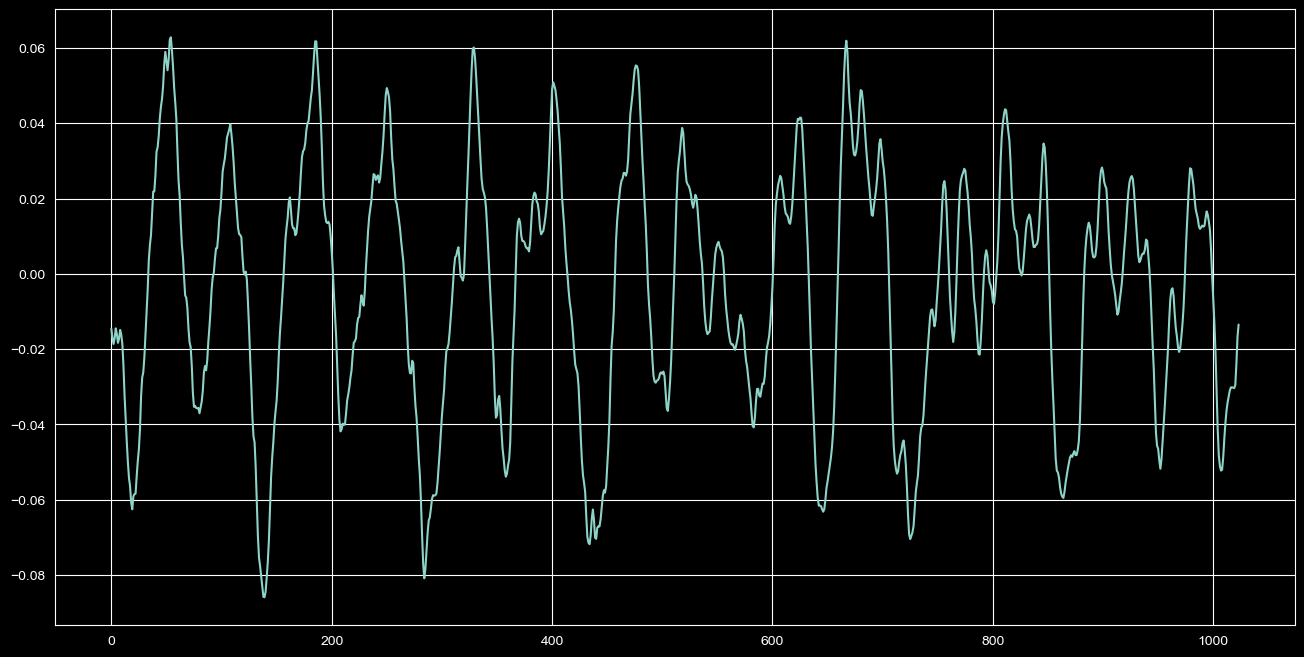

In [29]:
plt.figure(figsize=(16, 8))
plt.plot(windows[0, 0])

display.Audio(windows[0, 0], rate=train_dataset.sr)

Теперь нам надо применить косинусоидальный фильтр к сигналу из окна. Для этого с помощью `torch.hann_window` создадим косинусоидальный фильтр и умножим его поэлементно на все окна.

In [30]:
# Создаем косинусоидальное окно (окно Ханна) нужного размера
# Убедимся, что фильтр находится на том же устройстве, что и данные
filter = torch.hann_window(window_length=win_length, device=windows.device)

# Умножаем каждое окно на фильтр (используем broadcasting)
windows_with_applied_filter = windows * filter[None, None, :]


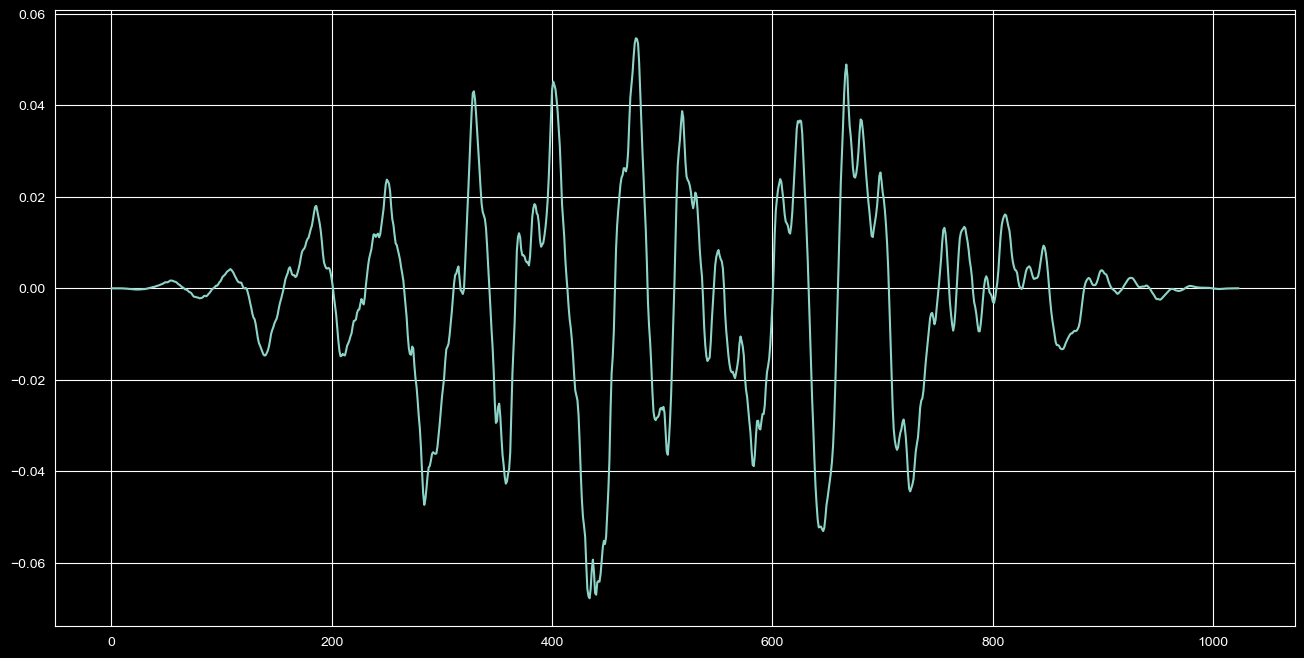

In [31]:
plt.figure(figsize=(16, 8))
plt.plot(windows_with_applied_filter[0, 0])

display.Audio(windows_with_applied_filter[0, 0], rate=train_dataset.sr)

С помощью `torch.fft.fft` примените дискретное преобразование фурье к каждому окну и возьмите первые `n_fft // 2 + 1` компоненты.

Дальше с помощью возведения элементов тензора в квадрат и `torch.abs()` получите магнитуды.

In [32]:
# Применяем дискретное преобразование Фурье вдоль последней оси (внутри каждого окна)
fft_features_full = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)

# Оставляем только положительные частоты (первые n_fft // 2 + 1 компоненты)
fft_features = fft_features_full[:, :, : n_fft // 2 + 1]

# Вычисляем магнитуды (мощность спектра)
fft_magnitudes = torch.abs(fft_features**2)

assert fft_magnitudes.shape == (32, 1497, 513)


Через `torchaudio.transforms.MelScale` создайте класс для перевода магнитуд в мел-шкалу.

In [35]:
# Создаем преобразование в мел-шкалу
melscale = torchaudio.transforms.MelScale(
    n_mels=n_mels,
    sample_rate=sr,
    n_stft=n_fft // 2 + 1
).to(fft_magnitudes.device)  # переносим на то же устройство, где и тензоры

Нелинейное преобразование для перевода в мел-шкалу выглядит следующим образом.

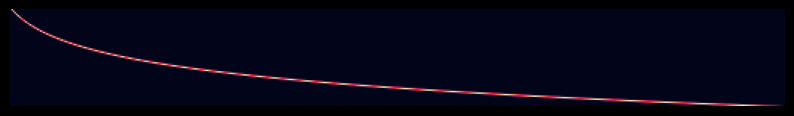

In [36]:
plt.figure(figsize=(10, 5))
plt.axis("off")
plt.imshow(melscale.fb.numpy().transpose())

Примените мел-шкалу к магнитудам.

In [37]:
# Меняем местами оси времени и частот: (32, 1497, 513) -> (32, 513, 1497)
transposed_magnitudes = fft_magnitudes.transpose(1, 2)

# Применяем фильтры мел-шкалы
mel_spectrogram = melscale(transposed_magnitudes)

# Проверяем итоговую размерность
assert mel_spectrogram.shape == (32, 64, 1497)


Сделайте обрезку значений по `1e-5` и примените `torch.log` для получения логарифмированной мел-спектрограммы.

In [38]:
# Ограничиваем минимальные значения и берем натуральный логарифм
logmel_spectrogram = torch.log(mel_spectrogram.clamp(min=1e-5))

# Проверяем итоговую размерность
assert logmel_spectrogram.shape == (32, 64, 1497)


Полученные логарифмированные мел-спектрограммы должны совпадать с референсными.

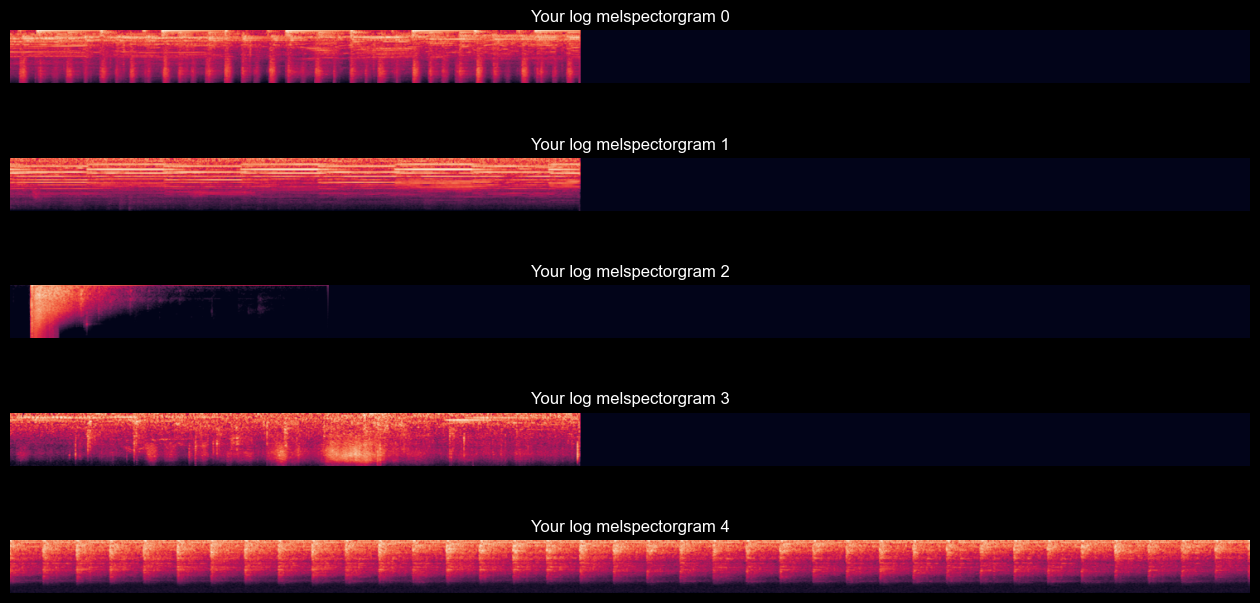

In [39]:
# нарисуем получившиеся значения
fig, axes = plt.subplots(5, figsize=(16, 8))

for i in range(5):
    axes[i].axis("off")
    axes[i].set_title(f"Your log melspectorgram {i}")
    axes[i].imshow(logmel_spectrogram[i].numpy())

Теперь оформим эту логику в функцию.

In [40]:
# ваша реализация
def compute_log_melspectrogram(wav_batch, lens, sr, device="cpu"):
    n_fft = 1024
    win_length = 1024
    hop_length = 256
    n_mels = 64

    # Убеждаемся, что входные тензоры на нужном устройстве
    wav_batch = wav_batch.to(device)
    if isinstance(lens, torch.Tensor):
        lens = lens.to(device)

    # Разбиваем сигнал на окна
    windows = wav_batch.unfold(dimension=-1, size=win_length, step=hop_length)

    # Создаем и применяем косинусоидальный фильтр (окно Ханна)
    filter_window = torch.hann_window(window_length=win_length, device=device)
    windows_with_applied_filter = windows * filter_window[None, None, :]

    # Применяем дискретное преобразование Фурье
    fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)
    # Берем только первые компоненты (положительные частоты)
    fft_features = fft_features[:, :, : n_fft // 2 + 1]
    # Вычисляем магнитуды (возводим в квадрат и берем модуль)
    fft_magnitudes = torch.abs(fft_features**2)

    # Подготавливаем и применяем фильтры мел-шкалы
    mel_scale = torchaudio.transforms.MelScale(
        n_mels=n_mels,
        sample_rate=sr,
        n_stft=n_fft // 2 + 1
    ).to(device)

    # Меняем местами оси: (Batch, Frames, Freqs) -> (Batch, Freqs, Frames)
    transposed_magnitudes = fft_magnitudes.transpose(1, 2)
    mel_spectrogram = mel_scale(transposed_magnitudes)

    # Ограничиваем минимальные значения и логарифмируем
    logmel_spectrogram = torch.log(mel_spectrogram.clamp(min=1e-5))

    # Длина уменьшается пропорционально шагу сдвига окна (hop_length)
    new_lens = lens // hop_length

    return logmel_spectrogram, new_lens


Финальная проверка.

In [41]:
assert torch.allclose(
    compute_log_melspectrogram_reference(wav_batch, lens, train_dataset.sr)[0],
    compute_log_melspectrogram(wav_batch, lens, train_dataset.sr)[0],
    atol=1e-5,
)

## Задание 4. Рекуррентная сеть для классификации аудиозаписей по логарифмированным мел-спектрограммам (1 балл)

Измените реализацию рекуррентной сети из задания 2, таким образом, чтобы она вместо сырого сигнала смогла принимать логарифмированные мел-спектрограммы:
1. Уберите шаги 1-2
2. Сделайте вход LSTM равным 64


**За реализацию архитектуры дается 0.5 балла.**

In [42]:
class RecurrentMelSpectClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        window_length=1024,
        hop_length=256,
        hidden=256,
        num_layers=2,
    ) -> None:
        super().__init__()

        self.window_length = window_length
        self.hop_length = hop_length
        self.hidden = hidden
        self.num_layers = num_layers

        # Входной размер теперь равен 64 (количество мел-фильтров)
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # Полносвязная сеть для классификации
        self.mlp = nn.Sequential(
            nn.Linear(2 * hidden * num_layers, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, lens):
        # x приходит с размерностью (Batch, n_mels, Frames)
        # Меняем оси для LSTM -> (Batch, Frames, n_mels)
        x = x.transpose(1, 2)

        # Подготавливаем длины для pack_padded_sequence
        if isinstance(lens, torch.Tensor):
            lens = lens.cpu().to(torch.int64)

        # Защита от выхода длин за пределы текущего размера тензора
        lens = torch.clamp(lens, min=1, max=x.shape[1])

        # Упаковываем последовательности, чтобы LSTM не обрабатывала нули паддинга
        packed_input = nn.utils.rnn.pack_padded_sequence(
            x, lengths=lens, batch_first=True, enforce_sorted=False
        )

        # Применяем LSTM (нам нужен только hidden state 'hn')
        _, (hn, _) = self.lstm(packed_input)

        # hn имеет размер (num_layers * num_directions, Batch, hidden_size)
        # Конкатенируем hidden states по всем слоям и направлениям по признаковой оси
        hidden_flattened = torch.cat([hn[i] for i in range(hn.size(0))], dim=1)

        # Пропускаем через полносвязную сеть для получения логитов классов
        logits = self.mlp(hidden_flattened)

        return logits


In [43]:
rnn_mel = RecurrentMelSpectClassifier()
rnn_mel.to(device)

optim = torch.optim.Adam(rnn_mel.parameters(), lr=3e-4)

Epoch 4


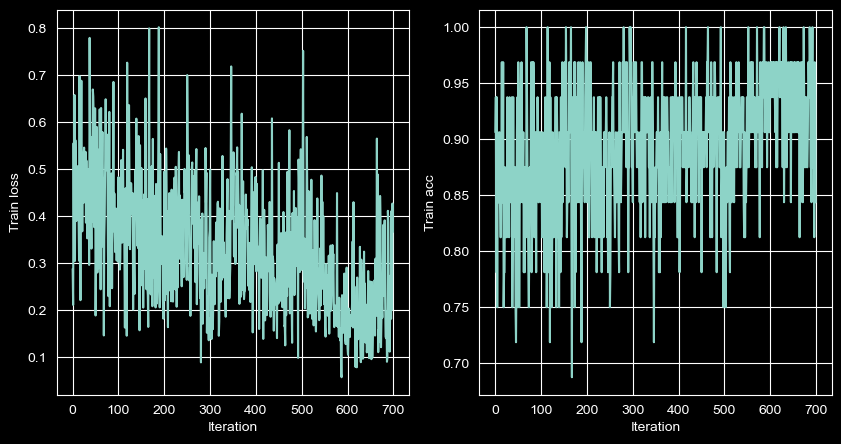

In [46]:
train_audio_clfr(
    rnn_mel,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    num_epochs=5,
    device="mps",
    verbose_num_iters=10,
)

Посчитаем метрики на валидационном датасете.

**Задание: для получения 0.5 балла сделайте подбор гиперпараметров и добейтесь accuracy модели выше 0.8 на валидационном датасете.**

/var/folders/nr/x_t3ckhs7mb149jhbr8w134r0000gn/T/ipykernel_84952/381278711.py:21: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 1497, 1024]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)
/var/folders/nr/x_t3ckhs7mb149jhbr8w134r0000gn/T/ipykernel_84952/381278711.py:21: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [7, 1497, 1024]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can expli

Val accuracy: 0.825668449197861


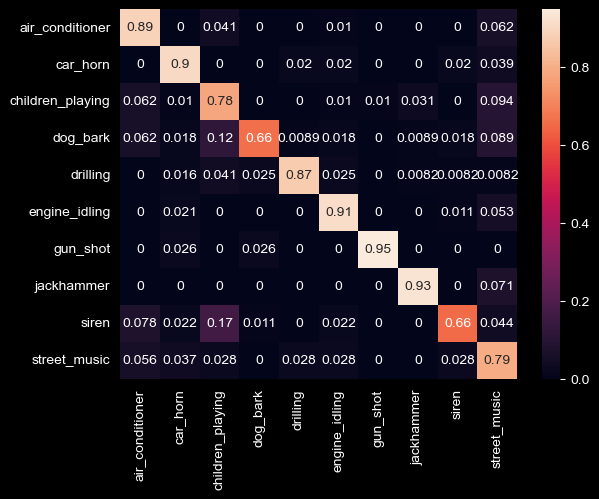

In [47]:
plot_confusion_matrix(
    rnn_mel,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

## Задание 5. Cверточная сеть для классификации аудиозаписей по мел-спектрограммам. (2 балла)

Легко заметить, что мелспектрограммы имеют четко выраженные паттерны - если приноровиться, то даже человек, посмотрев на мелспектрограмму, сможет _визуально_ проклассифицировать объект.

Это позволяет свести задачу классификации аудиозаписей к задаче классификации картинок.

Реализуем такую сверточную сеть:

* 2x (Conv2d 3x3 @ 16, BatchNorm2d, ReLU)
* MaxPool 2x2
* 2x (Conv2d 3x3 @ 32, BatchNorm2d, ReLU)
* MaxPool 2x2
* 2x (Conv2d 3x3 @ 64, BatchNorm2d, ReLU)
* MaxPool 2x2
* (Conv2d 3x3 @ 128, BatchNorm2d, ReLU)
* (Conv2d 2x2 @ 128, BatchNorm2d, ReLU)
* Global MaxPool
* Fully Connected 128, ReLU
* Fully Connected 10

Совет: подобная архитектура была реализована в [**PANNs: Large-Scale Pretrained Audio Neural Networks for Audio Pattern Recognition**](https://arxiv.org/pdf/1912.10211.pdf), можете использовать эту статью как референс.


**За реализацию архитектуры дается 1.5 балла.**

In [48]:
class CNN10(nn.Module):
    def __init__(self, num_classes=10, hidden=16):
        super().__init__()

        self.cnn_backbone = nn.Sequential(
            # Блок 1: 2x (Conv2d 3x3 @ 16, BatchNorm2d, ReLU) + MaxPool 2x2
            nn.Conv2d(in_channels=1, out_channels=hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden, out_channels=hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Блок 2: 2x (Conv2d 3x3 @ 32, BatchNorm2d, ReLU) + MaxPool 2x2
            nn.Conv2d(in_channels=hidden, out_channels=hidden * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 2),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden * 2, out_channels=hidden * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Блок 3: 2x (Conv2d 3x3 @ 64, BatchNorm2d, ReLU) + MaxPool 2x2
            nn.Conv2d(in_channels=hidden * 2, out_channels=hidden * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 4),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden * 4, out_channels=hidden * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Блок 4: (Conv2d 3x3 @ 128, BatchNorm2d, ReLU)
            nn.Conv2d(in_channels=hidden * 4, out_channels=hidden * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 8),
            nn.ReLU(),

            # Блок 5: (Conv2d 2x2 @ 128, BatchNorm2d, ReLU)
            nn.Conv2d(in_channels=hidden * 8, out_channels=hidden * 8, kernel_size=2, padding=0),
            nn.BatchNorm2d(hidden * 8),
            nn.ReLU()
        )

        # Полносвязная сеть для классификации
        # Fully Connected 128, ReLU
        # Fully Connected 10
        self.final_mlp = nn.Sequential(
            nn.Linear(hidden * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, lens):
        # x имеет размер (Batch, Freqs, Frames)
        # x[:, None, :, :] добавляет размерность каналов -> (Batch, 1, Freqs, Frames)
        z = self.cnn_backbone(x[:, None, :, :])

        # Global MaxPool - берем максимум по пространственным измерениям (H и W)
        z = torch.nn.functional.max_pool2d(z, kernel_size=z.size()[2:])[:, :, 0, 0]

        # Получаем итоговые логиты
        return self.final_mlp(z)


In [49]:
cnn = CNN10()
cnn.to(device)

optim = torch.optim.Adam(cnn.parameters(), lr=3e-4)

Epoch 19


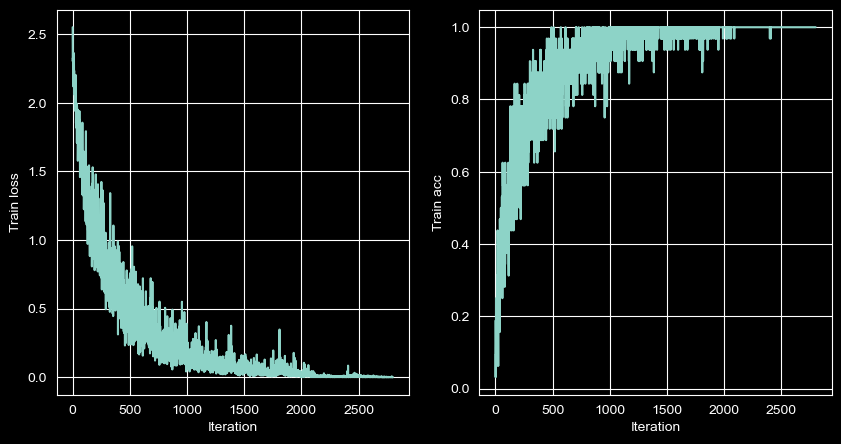

In [50]:
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    num_epochs=20,
)

**Задание: для получения 0.5 балла сделайте подбор гиперпараметров и добейтесь accuracy модели выше 0.85 на валидационном датасете.**

/var/folders/nr/x_t3ckhs7mb149jhbr8w134r0000gn/T/ipykernel_84952/381278711.py:21: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 1497, 1024]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)
/var/folders/nr/x_t3ckhs7mb149jhbr8w134r0000gn/T/ipykernel_84952/381278711.py:21: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [7, 1497, 1024]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can expli

Val accuracy: 0.9561497326203209


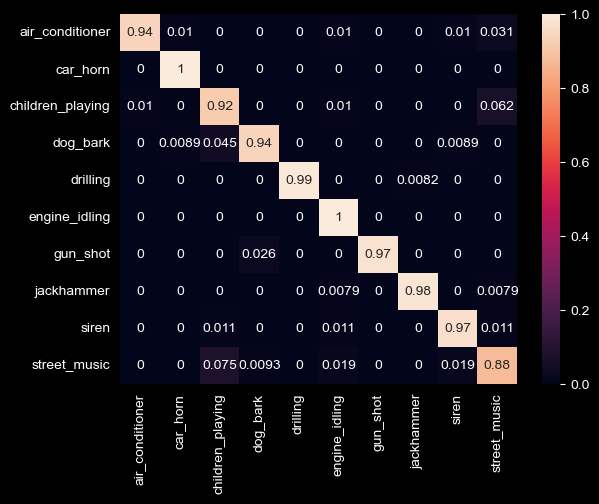

In [51]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

## Задание 6. Аугментация SpecAugment (2 балла)

Обычно датасеты с аудиозаписями довольно малы. Наш датасет тому пример - всего 4500 объектов в обучающей выборке. Обучение глубоких сетей с большим кол-вом параметров на таких датасетах часто ведет к переобучению и проседанию метрик на валидационном и тестовом датасетах.

Для борьбы с переобучением имеет смысл использовать аугментацию данных. Для мелспектрограмм была придумана аугментация под названием SpecAugment.

Смысл её очень прост - зануление спектрограммы по временным промежуткам и по мел-частотам:
1. Выбираются несколько временных промежутков ${[t^1_i, t^2_i]}$ и заполняют спектрограмму $s[t^1_i : t^2_i, :]$ значением $v$.

2. Выбираются несколько промежутков мелчастот ${[m^1_i, m^2_i]}$ и заполняют спектрограмму $s[:, m^1_i : m^2_i]$ значением $v$.

В качестве значения $v$ выбирают:
1. `'mean'`: среднее по спектрограмме
2. `'min'`: минимум по спектрограмме
3. `'max'`: максимум по спектрограмме
5. `v`: некоторая константа

Совет: описание аугментации можно найти здесь: [link](https://neurohive.io/ru/novosti/specaugment-novyj-metod-augmentacii-audiodannyh-ot-google-ai/), можете использовать эту ссылку как референс.

![specaugment](https://neurohive.io/wp-content/uploads/2019/04/image6.png)

В этом задании Вам предлагается реализовать аугментацию SpecAugment.

**За реализацию аугментации дается 1.5 балла.**


In [52]:
class SpectAugment:
    def __init__(
        self,
        filling_value="mean",
        n_freq_masks=2,
        n_time_masks=2,
        max_freq=10,
        max_time=50,
    ):

        self.filling_value = filling_value
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks
        self.max_freq = max_freq
        self.max_time = max_time

    def __call__(self, spect, lens):
        # spect: тензор мел-спектрограммы (Batch, n_mels, Frames)
        # lens: длины (в кадрах) для каждой записи в батче
        batch_size, n_mels, n_frames = spect.shape

        # Убедимся, что тензор на CPU, чтобы избежать ошибок с numpy
        spect_cpu = spect.cpu()

        for i in range(batch_size):
            # Выбираем значение для заполнения (v)
            if self.filling_value == "mean":
                fill_val = torch.mean(spect_cpu[i]).item()
            elif self.filling_value == "min":
                fill_val = torch.min(spect_cpu[i]).item()
            elif self.filling_value == "max":
                fill_val = torch.max(spect_cpu[i]).item()
            else:  # Если это константа
                fill_val = float(self.filling_value)

            current_frames = lens[i].item()  # реальная длина для этого сэмпла

            # Применяем маски частот (Frequency Masks)
            for _ in range(self.n_freq_masks):
                # Случайно выбираем ширину маски частот
                freq_mask_width = random.randint(1, self.max_freq)

                # Случайно выбираем стартовую мел-частоту (m^1_i)
                # Ограничиваем, чтобы маска не выходила за границы n_mels
                start_freq = random.randint(0, max(0, n_mels - freq_mask_width))

                # Заполняем выбранный диапазон частот
                spect_cpu[i, start_freq : start_freq + freq_mask_width, :current_frames] = fill_val

            # Применяем временные маски (Time Masks)
            for _ in range(self.n_time_masks):
                # Случайно выбираем ширину временной маски
                time_mask_width = random.randint(1, self.max_time)

                # Случайно выбираем стартовый временной кадр (t^1_i)
                # Ограничиваем, чтобы маска не выходила за пределы текущей длины
                start_time = random.randint(0, max(0, current_frames - time_mask_width))

                # Заполняем выбранный диапазон времени
                spect_cpu[i, :, start_time : start_time + time_mask_width] = fill_val

        # Возвращаем измененную спектрограмму на исходное устройство
        return spect_cpu.to(spect.device), lens

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/anaconda3/lib/python3.13/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 1497, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


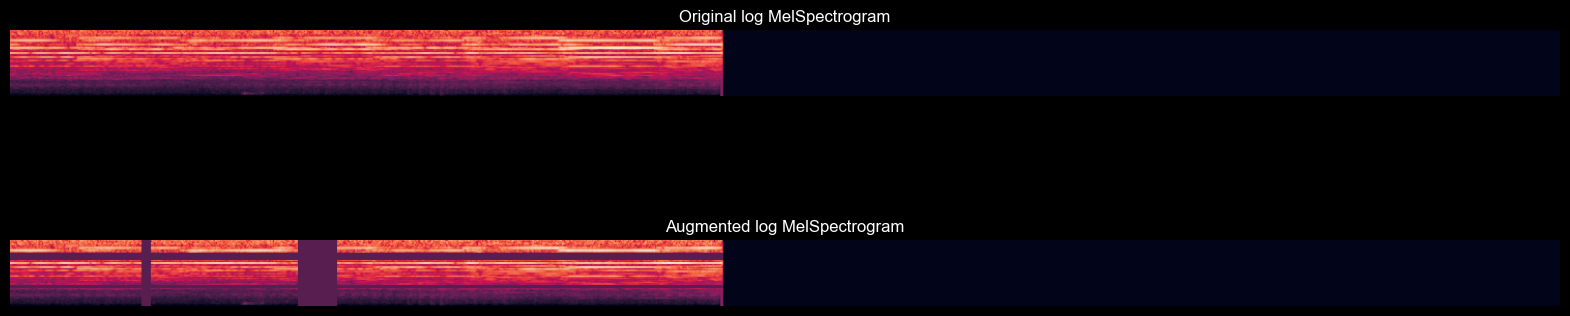

In [53]:
# применим аугментацию к данным
for batch in train_dataloader:
    break

x = batch["x"].to(device)
lens = batch["len"].to(device)
x_logmel, lens = compute_log_melspectrogram_reference(
    x, lens, sr=train_dataset.sr, device=device
)
x_logmel_augmented, lens = SpectAugment()(x_logmel, lens)

# нарисуем спектрограмму до и после аугментации
plt.figure(figsize=(20, 5))
plt.subplot(2, 1, 1)
plt.title("Original log MelSpectrogram")
plt.axis("off")
plt.imshow(x_logmel[0].cpu().numpy())

plt.subplot(2, 1, 2)
plt.title("Augmented log MelSpectrogram")
plt.axis("off")
plt.imshow(x_logmel_augmented[0].cpu().numpy())

plt.show()

In [54]:
cnn = CNN10()
cnn.to(device)

optim = torch.optim.Adam(cnn.parameters(), lr=3e-4)

Epoch 19


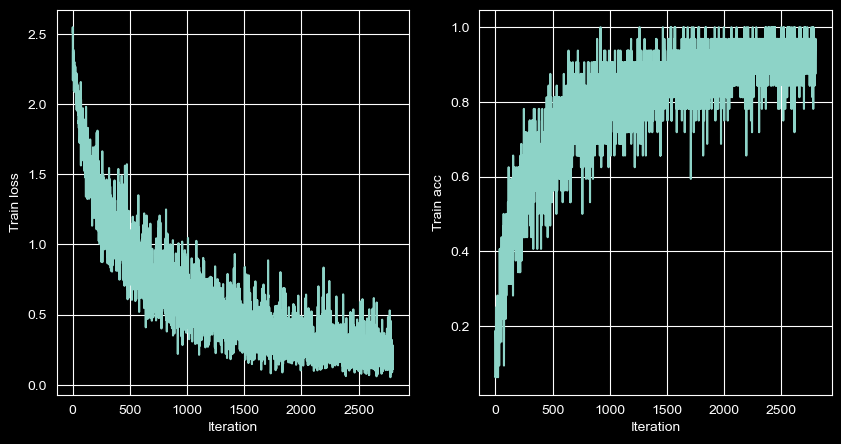

In [55]:
# обучим модель на данных с аугментациями
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    augmentation=SpectAugment(),
    num_epochs=20,
)

**Задание: для получения 0.5 балла сделайте подбор параметров аугментации и добейтесь accuracy модели выше 0.9 на валидационном датасете.**

/var/folders/nr/x_t3ckhs7mb149jhbr8w134r0000gn/T/ipykernel_84952/381278711.py:21: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 1497, 1024]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)


Val accuracy: 0.8406417112299466


/var/folders/nr/x_t3ckhs7mb149jhbr8w134r0000gn/T/ipykernel_84952/381278711.py:21: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [7, 1497, 1024]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)


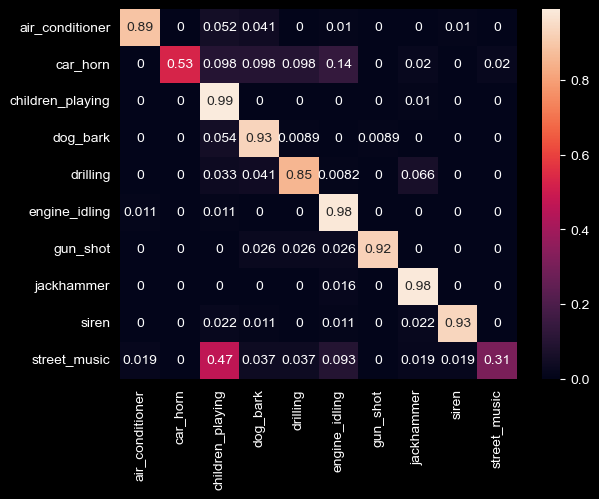

In [56]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)